# Péndulo en mecánica con sus correcciones en diferentes órdenes.

En mecánica sabemos que el péndulo es uno de los problemas más inmediatos que se nos presenta que tiene un montón de aplicaciones y rica teoría. Claro está que hay algo escondido detrás de esta simplicidad: **aproximaciones**.

Pero ahora tomemos el caso general y veamos que tan buena es la aproximación de ángulos pequeños.
Sabemos que por la ecuación de movimiento del péndulo usando Newton o Lagrange es $\ddot{\theta} +\omega^{2} \sin\theta=0$, donde $\omega_{0}^{2}= g/L$ siendo L la longitud del péndulo y g la constante de la gravedad donde oscile el péndulo. Con la aproximación de ángulos pequeños o aproximación **paraxial** formalmente nos permiten tomar $\theta << 1$ por lo que $\sin \theta \approx \theta$ y nos libera inmediatamente el periodo de oscilación $T= \frac{2\pi}{\omega}$. 

Esto nos permite tener un método para medir la constante de la gravitación conociendo el ángulo de oscilación (pequeño) y la longitud del péndulo. Claro está que suponemos que la cuerda es indeformable (otra aproximación) y que no hay fricción con respecto del aire o el pivote donde oscila (donde igualmente se iría energía por calentamiento). Todas estas aproximaciones si es un ángulo muy pequeño son arreglables pero ¿hasta qué valor del ángulo?

Esto es un resultado muy importante, el péndulo bajo estas aproximaciones tiene un periodo independiente de la longitud de este, por lo que hay una similaridad mecánica de grado k=1, implicando que no importa que tan largo escalemos el sistema, siempre será el mismo periodo (**tarea: ¿pasaría lo mismo al variar la masa?**).

Pero ¿qué correcciones tiene el péndulo cuando la aproximación de ángulos pequeños ya no funciona?
Bueno, en esta situación el comportamiento del seno con su no linealidad afecta el periodo y la frecuencia de oscilación deja de ser $\omega_{0}$, podemos imaginar lo siguiente, para el caso lineal $F \propto -\theta$ pero para el caso no lineal $F \propto - \sin \theta$, entonces cuanto sea más ángulo, la fuerza de restitución hacia el centro será más débil en realidad que respecto al caso paraxial.

¿Cómo obtener las correcciones para el caso realista? 
* **Teoría de perturbaciones**
* **Integrales elípticas**
* **Aproximación de ángulos Grandes**

Hoy veremos el método más sencillo, mediante integrales elípticas para evitar las ecuaciones de Duffing.

Sea $\theta_{0}$ el ángulo más grande que demarca el movimiento, el periodo es 4 veces el tiempo desde el punto más bajo hasta este ángulo.
Usando cuadratura nosotros podemos hallar la integral:

$ \displaystyle  T = 4 \sqrt{\frac{L}{2g}}  \int_{0}^{\theta_{0}} \frac{d\theta}{\sqrt{\cos \theta - \cos \theta_{0}}}$


Si tomamos el cambio de variable: $\sin \xi = \sin \frac{1}{2}\theta / \sin \frac{1}{2}\theta_{0}$, hallamos que:

$ \displaystyle T = 2 \sqrt{L/g} \int_{0}^{\pi/2} \frac{d\xi}{\sqrt{1-k^{2}\sin^{2}\xi}} = 2 \sqrt{L/g} \quad K(k)$  (**Tarea: hacer los desarrollos**)

Donde $K(k)$ es una función elíptica completa de primera especie (**tarea: ¿cuánto vale k? Debe ser $\sin(\theta_{0}/2)$**)

Ahora tomando la aproximación paraxial nuevamente (vieja amiga), esto nos permite hacer una expansión binomial en la integral al tener que $(1-x)^{1/2} <<1$ y así al expandir e integrar, evaluar y sustituir (**tarea**), llegamos a que:

$T = 2\pi \sqrt{(L/g)} \left( 1 + \frac{1}{16} \theta_{0}^{2} + \frac{11}{3072}\theta_{0}^{4} + ... \right)$

Obteniendo así las correcciones de grado superior para el periodo.

Bibliografía:
* Tablas y fórmulas matemáticas Schaum's
* Mecánica Landau Lifschitz


### Veamos justamente que tan buena es la aproximación para diferentes ángulos y con la integración numérica de la integral sin tomar aproximación alguna para ver que tanto divergen:

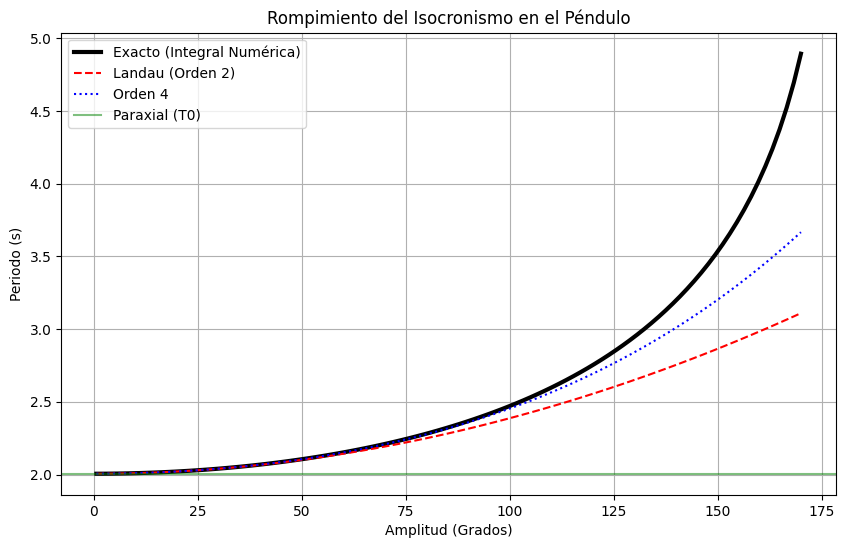

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson  

L = 1 #Longitud de la cuerda
g = 9.81 # Gravedad

theta_max = np.radians(170)
amplitudes = np.linspace(0.01, theta_max, 100)

# 1. Definir T_0 (escalar) y las aproximaciones
T_0 = 2 * np.pi * np.sqrt(L/g)
T_approx_1 = T_0 * (1 + amplitudes**2 / 16)
T_approx_2 = T_0 * (1 + amplitudes**2 / 16 + 11 * amplitudes**4 / 3072)

T_exact = []

# Definimos el dominio de integración auxiliar (xi va de 0 a pi/2 siempre)
xi_axis = np.linspace(0, np.pi/2, 1000) 

for phi_0 in amplitudes:
    # a) Calcular k para esta amplitud específica
    k = np.sin(phi_0 / 2)
    
    # b) Calcular el integrando
    # OJO: Validamos que no haya división por cero (aunque con 170° no debería pasar)
    integrand = 1 / np.sqrt(1 - k**2 * np.sin(xi_axis)**2)
    
    # c) Integrar usando Simpson
    K_val = simpson(integrand, x=xi_axis)
    
    # d) Calcular el Periodo Total y guardar
    T_val = 4 * np.sqrt(L/g) * K_val
    T_exact.append(T_val)

T_exact = np.array(T_exact) 

# 5. Gráficas
plt.figure(figsize=(10,6))
plt.plot(np.degrees(amplitudes), T_exact, label='Exacto (Integral Numérica)', linewidth=3, color='black')
plt.plot(np.degrees(amplitudes), T_approx_1, '--', label='Landau (Orden 2)', color='red')
plt.plot(np.degrees(amplitudes), T_approx_2, ':', label='Orden 4', color='blue')

# Usamos T_0 
plt.axhline(T_0, color='green', alpha=0.5, label='Paraxial (T0)')

plt.xlabel('Amplitud (Grados)')
plt.ylabel('Periodo (s)')
plt.title('Rompimiento del Isocronismo en el Péndulo')
plt.legend()
plt.grid(True)
plt.show()

$\ddot{\theta} + \gamma \dot{\theta} + \omega_{0}^{2}\sin\theta =0$